## 상관분석
```txt
1. 변수 간 관계 파악( 문제 정의 단계 )
머신러닝은 입력이 출력에 얼마나 영향을 주는지 찾는 과정
예를 들어:
공부시간 vs 시험점수
온도    vs 전력사용량
광고비  vs 매출

상관 분석을 하면 어떤 변수가 결과에 영향을 줄 가능성이 높은지 미리 알 수 있다.

BMI는 키와 몸무게 계산된 값

2. 모델( 알고리즘 ) 선택 힌트 제공
상황                                해석
--------------------------------------------------------------------------------
강산 선형 상관관계                     선형회귀 적합
상관 거의 없음                        비선형 모델 고려( 의사결정나무, 랜덤포레스트[앙상블] )

3. 이상치 발견
산점도 + 상관분석을 함께 보면
이상치가 결과를 왜곡하는지 확인 가능
```

In [13]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 한글 폰트 관련
from matplotlib import rc
path = "../malgun.ttf"
font_name = fm.FontProperties(fname=path).get_name()
rc('font', family=font_name)
plt.rc('font', family="Malgun Gothic")

In [14]:
import warnings
warnings.filterwarnings(action='ignore')

In [15]:
df = pd.read_csv("../data/trade_apt_api.csv")

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 318 entries, 0 to 317
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   거래금액     318 non-null    int64  
 1   건축년도     318 non-null    int64  
 2   년        318 non-null    int64  
 3   지역명      318 non-null    str    
 4   아파트      318 non-null    str    
 5   월        318 non-null    int64  
 6   일        318 non-null    int64  
 7   전용면적     318 non-null    float64
 8   지번       318 non-null    str    
 9   지역코드     318 non-null    int64  
 10  층        318 non-null    int64  
 11  해제사유발생일  318 non-null    str    
 12  해제여부     318 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 32.4 KB


In [17]:
df.columns

Index(['거래금액', '건축년도', '년', '지역명', '아파트', '월', '일', '전용면적', '지번', '지역코드', '층',
       '해제사유발생일', '해제여부'],
      dtype='str')

In [18]:
# X = df.iloc[:,:-1].values
# y = df.iloc[:,-1]

In [19]:
df_corr = df[['거래금액','건축년도','전용면적','층']]
df_corr

,거래금액,건축년도,전용면적,층
0,80000,2002,84.8200,1
1,209000,2008,163.3300,13
2,160000,2008,158.9900,4
3,96000,2008,116.0300,5
4,32000,2003,48.5400,7
...,...,...,...,...
313,86470,2000,60.0000,1
314,86500,2000,60.0000,1
315,135000,2019,59.6737,13
316,120000,2008,114.9310,9


In [20]:
corr = df_corr.corr()
corr

,거래금액,건축년도,전용면적,층
거래금액,1.000000,0.405903,0.707195,0.223960
건축년도,0.405903,1.000000,0.085323,0.212113
전용면적,0.707195,0.085323,1.000000,-0.016338
층,0.223960,0.212113,-0.016338,1.000000


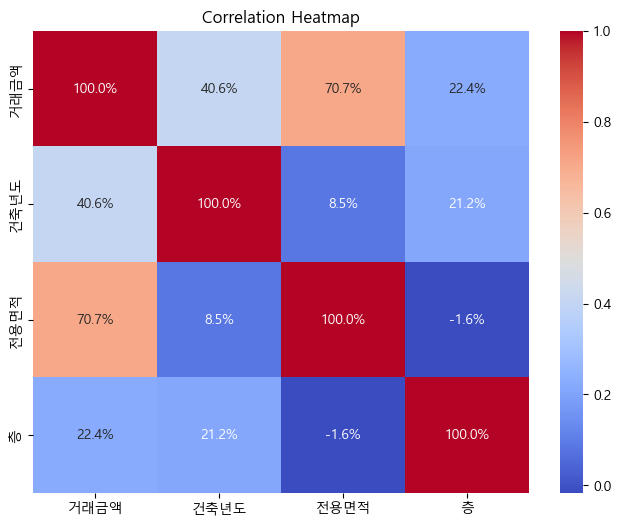

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".1%", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

```txt
상관계수 표 해석

상관계수( r )
  r = 1: 완전한( 정 ) 선형관계
  r = -1: 완전한( 부 ) 선형관계
  r = 0: 선형 관계 없음

크기기준 - 절대값을 씌워줌
  r < 0.3 약한 상관관계
  0.3 <= |r| <0.7: 중간정도의 상관관계
  |r| >= 0.7 강한 상관 관계

거래금액과 다른 변수들과 상관관계

거래금액 vs 건축년도 : 0.4059 -> 양의 상관( 중간정도 )
  건축년도가 최근일수록 거래금액이 비싸지는 경향이 있다.
  신축일수록 비싸고, 구축일수록 상대적으로 싸다

거래금액과 vs 전용면적: 0.707195
  0.7보다 크니까 강한 양의 상관관계
  전용면적이 클수록 거래금액이 같이 증가하는  패턴을 보인다.
  집이 클수록 비싸다

거래금액 vs 층: 0.223960

약한 양의 상관
  층수가 높을 수록 약간 더 비싼 경향은 있디만 그 영향력이 크지는 않을 것이다.
  저층보다 고층이 조금 더 비싼 경향은 있지만,
  면적이나 건축년도 만큼 가격을 좌우 하지는 않을 것이다.


독립변수( 입력값 )들 끼리의 관계

건축년도 vs 전용면적: 0.085323( 8.5% ) - 거의 상관 없음
  신축이라고 해서 반드시 큰 평형만 있는 것도 아니고 
  구축이라고 해서 항상 작은 형평만 있는 것도 아님.

건축년도 vs 층: 0.21223
  약한 양의 상관관계
  비교적 최근에 지어진 아파트 일수록 층수가 조금 더 높은 경향이 있다.
  고층아파트가 최근에 많이 지어진 현실과 어느정도 부합

전용면적 vs 층: -0.016338
  상관 거의 0
  평형과 층수 사이에는 특별한 성형관계가 있다고 볼 수 없다.
  큰 평형이 고층, 저층에만 몰려 있다기 보다 여러 층에 고르게 분포 하지않나??

```